# Week 2: Data Collection, Cleaning, and Preprocessing for Logistics Analysis

**Internship Role:** Logistics Data Analyst Intern  
**Organization:** Yuva Intern  
**Prepared by:** Japkirat Kaur  

## Project Objective
The objective of this project is to develop and document a systematic data preprocessing pipeline for logistics data. The project focuses on data collection and understanding, data quality assessment, handling missing values, duplicate detection, data type correction, outlier analysis, categorical data consistency, normalization and standardization, and final data quality validation.





## 1. Data Collection and Initial Dataset Understanding

### Data Source
This project uses the publicly available **Cargo 2000 Freight Tracking and Tracing** dataset from the UCI Machine Learning Repository. The dataset contains anonymized air-freight tracking and tracing information and is used here to demonstrate a systematic logistics data cleaning and preprocessing workflow.

Before applying any cleaning technique, the original dataset is inspected to understand its structure, dimensions, variables, data types, and potential data-quality issues.


In [ ]:
import pandas as pd
file_path = "/content/c2k_data_comma.csv"

df = pd.read_csv(file_path)

df.head()

,nr,i1_legid,i1_rcs_p,i1_rcs_e,i1_dep_1_p,i1_dep_1_e,i1_dep_1_place,i1_rcf_1_p,i1_rcf_1_e,i1_rcf_1_place,...,o_dep_3_p,o_dep_3_e,o_dep_3_place,o_rcf_3_p,o_rcf_3_e,o_rcf_3_place,o_dlv_p,o_dlv_e,o_hops,legs
0,0.0,5182.0,199.0,218.0,210.0,215.0,609.0,935.0,736.0,256.0,...,?,?,?,?,?,?,780.0,434.0,1.0,2.0
1,1.0,6523.0,844.0,584.0,90.0,297.0,700.0,1935.0,1415.0,431.0,...,?,?,?,?,?,?,3870.0,445.0,1.0,2.0
2,2.0,5878.0,4380.0,4119.0,90.0,280.0,456.0,905.0,547.0,700.0,...,?,?,?,?,?,?,550.0,1520.0,1.0,1.0
3,3.0,1275.0,759.0,169.0,240.0,777.0,173.0,340.0,577.0,349.0,...,?,?,?,?,?,?,3780.0,159.0,1.0,1.0
4,4.0,8117.0,1597.0,1485.0,150.0,241.0,411.0,585.0,612.0,128.0,...,?,?,?,?,?,?,4140.0,4797.0,2.0,1.0


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 3943
Number of columns: 98
Dataset shape: (3943, 98)


## 2. Initial Data Quality Assessment

Before modifying the dataset, an initial data-quality audit is performed. This assessment examines column names, data types, missing values, duplicate records, and other potential inconsistencies. Identifying these issues before cleaning helps ensure that preprocessing decisions are based on evidence rather than assumptions.

In [ ]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Column Names:
['nr', 'i1_legid', 'i1_rcs_p', 'i1_rcs_e', 'i1_dep_1_p', 'i1_dep_1_e', 'i1_dep_1_place', 'i1_rcf_1_p', 'i1_rcf_1_e', 'i1_rcf_1_place', 'i1_dep_2_p', 'i1_dep_2_e', 'i1_dep_2_place', 'i1_rcf_2_p', 'i1_rcf_2_e', 'i1_rcf_2_place', 'i1_dep_3_p', 'i1_dep_3_e', 'i1_dep_3_place', 'i1_rcf_3_p', 'i1_rcf_3_e', 'i1_rcf_3_place', 'i1_dlv_p', 'i1_dlv_e', 'i1_hops', 'i2_legid', 'i2_rcs_p', 'i2_rcs_e', 'i2_dep_1_p', 'i2_dep_1_e', 'i2_dep_1_place', 'i2_rcf_1_p', 'i2_rcf_1_e', 'i2_rcf_1_place', 'i2_dep_2_p', 'i2_dep_2_e', 'i2_dep_2_place', 'i2_rcf_2_p', 'i2_rcf_2_e', 'i2_rcf_2_place', 'i2_dep_3_p', 'i2_dep_3_e', 'i2_dep_3_place', 'i2_rcf_3_p', 'i2_rcf_3_e', 'i2_rcf_3_place', 'i2_dlv_p', 'i2_dlv_e', 'i2_hops', 'i3_legid', 'i3_rcs_p', 'i3_rcs_e', 'i3_dep_1_p', 'i3_dep_1_e', 'i3_dep_1_place', 'i3_rcf_1_p', 'i3_rcf_1_e', 'i3_rcf_1_place', 'i3_dep_2_p', 'i3_dep_2_e', 'i3_dep_2_place', 'i3_rcf_2_p', 'i3_rcf_2_e', 'i3_rcf_2_place', 'i3_dep_3_p', 'i3_dep_3_e', 'i3_dep_3_place', 'i3_rcf_3_p', 'i3_r

In [ ]:
missing_count = df.isnull().sum()

missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})

missing_summary = missing_summary[missing_summary["Missing_Count"] > 0]

missing_summary = missing_summary.sort_values(
    by="Missing_Percentage",
    ascending=False
)

print("Number of columns containing missing values:", len(missing_summary))
display(missing_summary)

Number of columns containing missing values: 98


,Missing_Count,Missing_Percentage
nr,1,0.025361
i1_legid,1,0.025361
i1_rcs_p,1,0.025361
i1_rcs_e,1,0.025361
i1_dep_1_p,1,0.025361
...,...,...
o_rcf_3_place,1,0.025361
o_dlv_p,1,0.025361
o_dlv_e,1,0.025361
o_hops,1,0.025361


In [ ]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Total duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_percentage, 2), "%")

Total duplicate rows: 0
Duplicate percentage: 0.0 %


### Duplicate Data Assessment

The dataset was examined for exact duplicate records using the pandas `duplicated()` method. No duplicate rows were identified, resulting in a duplicate rate of 0.0%.

Therefore, no records were removed at this stage. Removing rows without evidence of duplication could result in unnecessary information loss and could affect the reliability of subsequent logistics analysis. The original observations were consequently retained.

In [ ]:
print("Columns with less than 5% missing:",
      (missing_summary["Missing_Percentage"] < 5).sum())

print("Columns with 5% to 20% missing:",
      ((missing_summary["Missing_Percentage"] >= 5) &
       (missing_summary["Missing_Percentage"] < 20)).sum())

print("Columns with 20% to 50% missing:",
      ((missing_summary["Missing_Percentage"] >= 20) &
       (missing_summary["Missing_Percentage"] < 50)).sum())

print("Columns with 50% or more missing:",
      (missing_summary["Missing_Percentage"] >= 50).sum())

print("\nHighest missing percentage:",
      round(missing_summary["Missing_Percentage"].max(), 2), "%")

print("Lowest missing percentage:",
      round(missing_summary["Missing_Percentage"].min(), 2), "%")

Columns with less than 5% missing: 98
Columns with 5% to 20% missing: 0
Columns with 20% to 50% missing: 0
Columns with 50% or more missing: 0

Highest missing percentage: 0.03 %
Lowest missing percentage: 0.03 %


In [ ]:
rows_with_missing = df[df.isnull().any(axis=1)]

print("Total rows containing at least one missing value:", len(rows_with_missing))
print("Percentage of rows containing missing values:",
      round((len(rows_with_missing) / len(df)) * 100, 2), "%")

display(rows_with_missing)

Total rows containing at least one missing value: 1
Percentage of rows containing missing values: 0.03 %


,nr,i1_legid,i1_rcs_p,i1_rcs_e,i1_dep_1_p,i1_dep_1_e,i1_dep_1_place,i1_rcf_1_p,i1_rcf_1_e,i1_rcf_1_place,...,o_dep_3_p,o_dep_3_e,o_dep_3_place,o_rcf_3_p,o_rcf_3_e,o_rcf_3_place,o_dlv_p,o_dlv_e,o_hops,legs
3942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_clean = df.dropna(how="all").copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)
print("Remaining missing values:", df_clean.isnull().sum().sum())

Original dataset shape: (3943, 98)
Cleaned dataset shape: (3942, 98)
Remaining missing values: 0


### Missing-Value Treatment and Justification

The raw CSV contained 3,943 rows and 98 columns. Missing-value analysis showed that all 98 columns contained a missing value; however, further investigation revealed that these missing values were concentrated entirely within a single completely empty row. This row represented approximately 0.03% of the raw records.

The completely empty row was removed rather than imputed. Mean, median, mode, or other imputation techniques were not appropriate because the row contained no observed information that could support a meaningful estimate. Imputing all 98 fields would effectively create an artificial logistics record and could introduce bias into subsequent analysis.

After removing the empty row, the working dataset contained 3,942 rows and 98 columns with zero remaining missing values. The original DataFrame was retained separately, while subsequent preprocessing is performed on a cleaned copy to support transparent before-and-after validation.

In [ ]:
dtype_summary = pd.DataFrame({
    "Column": df_clean.columns,
    "Data_Type": df_clean.dtypes.astype(str).values
})

print("Data type counts:")
print(df_clean.dtypes.value_counts())

display(dtype_summary)

Data type counts:
object     72
float64    26
Name: count, dtype: int64


,Column,Data_Type
0,nr,float64
1,i1_legid,float64
2,i1_rcs_p,float64
3,i1_rcs_e,float64
4,i1_dep_1_p,float64
...,...,...
93,o_rcf_3_place,object
94,o_dlv_p,float64
95,o_dlv_e,float64
96,o_hops,float64


In [ ]:
object_columns = df_clean.select_dtypes(include="object").columns

print("Number of object columns:", len(object_columns))

for col in object_columns:
    print("\nColumn:", col)
    print("Sample values:", df_clean[col].dropna().head(3).tolist())

Number of object columns: 72

Column: i1_dep_2_p
Sample values: ['?', '?', '?']

Column: i1_dep_2_e
Sample values: ['?', '?', '?']

Column: i1_dep_2_place
Sample values: ['?', '?', '?']

Column: i1_rcf_2_p
Sample values: ['?', '?', '?']

Column: i1_rcf_2_e
Sample values: ['?', '?', '?']

Column: i1_rcf_2_place
Sample values: ['?', '?', '?']

Column: i1_dep_3_p
Sample values: ['?', '?', '?']

Column: i1_dep_3_e
Sample values: ['?', '?', '?']

Column: i1_dep_3_place
Sample values: ['?', '?', '?']

Column: i1_rcf_3_p
Sample values: ['?', '?', '?']

Column: i1_rcf_3_e
Sample values: ['?', '?', '?']

Column: i1_rcf_3_place
Sample values: ['?', '?', '?']

Column: i2_legid
Sample values: ['573', '13946', '?']

Column: i2_rcs_p
Sample values: ['3315', '2964', '?']

Column: i2_rcs_e
Sample values: ['2880', '2888', '?']

Column: i2_dep_1_p
Sample values: ['300', '180', '?']

Column: i2_dep_1_e
Sample values: ['696', '239', '?']

Column: i2_dep_1_place
Sample values: ['431', '257', '?']

Column: 

In [ ]:
question_counts = (df_clean.astype(str) == "?").sum()
question_counts = question_counts[question_counts > 0].sort_values(ascending=False)

print("Columns containing '?' placeholders:", len(question_counts))
print("Total '?' placeholders:", question_counts.sum())

display(question_counts.to_frame(name="Question_Mark_Count"))

Columns containing '?' placeholders: 72
Total '?' placeholders: 210186


,Question_Mark_Count
i3_dep_3_p,3934
i3_rcf_3_place,3934
i3_dep_3_e,3934
i3_dep_3_place,3934
i3_rcf_3_p,3934
...,...
i2_rcf_1_place,1318
i2_rcf_1_e,1318
i2_rcf_1_p,1318
i2_dep_1_place,1318


In [ ]:
question_summary = pd.DataFrame({
    "Question_Mark_Count": question_counts,
    "Question_Mark_Percentage": (question_counts / len(df_clean)) * 100
})

question_summary = question_summary.sort_values(
    "Question_Mark_Percentage",
    ascending=False
)

print("Columns with less than 5% '?':",
      (question_summary["Question_Mark_Percentage"] < 5).sum())

print("Columns with 5% to 20% '?':",
      ((question_summary["Question_Mark_Percentage"] >= 5) &
       (question_summary["Question_Mark_Percentage"] < 20)).sum())

print("Columns with 20% to 50% '?':",
      ((question_summary["Question_Mark_Percentage"] >= 20) &
       (question_summary["Question_Mark_Percentage"] < 50)).sum())

print("Columns with 50% or more '?':",
      (question_summary["Question_Mark_Percentage"] >= 50).sum())

display(question_summary)

Columns with less than 5% '?': 0
Columns with 5% to 20% '?': 0
Columns with 20% to 50% '?': 12
Columns with 50% or more '?': 60


,Question_Mark_Count,Question_Mark_Percentage
i3_dep_3_p,3934,99.797057
i3_rcf_3_place,3934,99.797057
i3_dep_3_e,3934,99.797057
i3_dep_3_place,3934,99.797057
i3_rcf_3_p,3934,99.797057
...,...,...
i2_rcf_1_place,1318,33.434805
i2_rcf_1_e,1318,33.434805
i2_rcf_1_p,1318,33.434805
i2_dep_1_place,1318,33.434805


In [ ]:
bins = [0, 50, 75, 90, 95, 100]
labels = ["0-50%", "50-75%", "75-90%", "90-95%", "95-100%"]

severity = pd.cut(
    question_summary["Question_Mark_Percentage"],
    bins=bins,
    labels=labels,
    include_lowest=True
).value_counts().sort_index()

print(severity)

Question_Mark_Percentage
0-50%      12
50-75%     24
75-90%      6
90-95%      6
95-100%    24
Name: count, dtype: int64


In [ ]:
import numpy as np

df_clean = df_clean.replace("?", np.nan)

print("Total missing values after converting '?' to NaN:",
      df_clean.isnull().sum().sum())

print("Columns containing missing values:",
      (df_clean.isnull().sum() > 0).sum())

Total missing values after converting '?' to NaN: 210186
Columns containing missing values: 72


In [ ]:
missing_pct = df_clean.isnull().mean() * 100

high_missing_columns = missing_pct[missing_pct >= 90].sort_values(ascending=False)

print("Columns with 90% or more missing values:", len(high_missing_columns))
display(high_missing_columns.to_frame(name="Missing_Percentage"))

Columns with 90% or more missing values: 30


,Missing_Percentage
i3_rcf_3_e,99.797057
i3_rcf_3_place,99.797057
i3_dep_3_p,99.797057
i3_dep_3_e,99.797057
i3_dep_3_place,99.797057
i3_rcf_3_p,99.797057
i2_rcf_3_p,99.644850
i2_dep_3_place,99.644850
i2_rcf_3_place,99.644850
i2_rcf_3_e,99.644850


In [ ]:
df_processed = df_clean.drop(columns=high_missing_columns.index).copy()

print("Shape before removing high-missing columns:", df_clean.shape)
print("Shape after removing high-missing columns:", df_processed.shape)
print("Number of columns removed:", len(high_missing_columns))
print("Number of columns retained:", df_processed.shape[1])

Shape before removing high-missing columns: (3942, 98)
Shape after removing high-missing columns: (3942, 68)
Number of columns removed: 30
Number of columns retained: 68


In [ ]:
remaining_missing = df_processed.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

remaining_summary = pd.DataFrame({
    "Missing_Count": remaining_missing,
    "Missing_Percentage": (remaining_missing / len(df_processed)) * 100
}).sort_values("Missing_Percentage", ascending=False)

print("Columns still containing missing values:", len(remaining_summary))
print("Total remaining missing values:", remaining_missing.sum())

display(remaining_summary)

Columns still containing missing values: 42
Total remaining missing values: 94698


,Missing_Count,Missing_Percentage
i2_dep_2_place,3151,79.934044
i2_dep_2_e,3151,79.934044
i2_rcf_2_p,3151,79.934044
i2_dep_2_p,3151,79.934044
i2_rcf_2_place,3151,79.934044
i2_rcf_2_e,3151,79.934044
i1_dep_2_place,2747,69.685439
i1_rcf_2_p,2747,69.685439
i1_dep_2_p,2747,69.685439
i1_dep_2_e,2747,69.685439


In [ ]:
missing_type_summary = pd.DataFrame({
    "Data_Type": df_processed[remaining_summary.index].dtypes.astype(str),
    "Missing_Count": remaining_summary["Missing_Count"],
    "Missing_Percentage": remaining_summary["Missing_Percentage"]
})

print("Data types among columns with remaining missing values:")
print(missing_type_summary["Data_Type"].value_counts())

display(missing_type_summary)

Data types among columns with remaining missing values:
Data_Type
object    42
Name: count, dtype: int64


,Data_Type,Missing_Count,Missing_Percentage
i2_dep_2_place,object,3151,79.934044
i2_dep_2_e,object,3151,79.934044
i2_rcf_2_p,object,3151,79.934044
i2_dep_2_p,object,3151,79.934044
i2_rcf_2_place,object,3151,79.934044
i2_rcf_2_e,object,3151,79.934044
i1_dep_2_place,object,2747,69.685439
i1_rcf_2_p,object,2747,69.685439
i1_dep_2_p,object,2747,69.685439
i1_dep_2_e,object,2747,69.685439


In [ ]:
unique_summary = pd.DataFrame({
    "Unique_Non_Null_Values": df_processed[remaining_summary.index].nunique(),
    "Missing_Percentage": remaining_summary["Missing_Percentage"]
}).sort_values("Missing_Percentage", ascending=False)

display(unique_summary)

,Unique_Non_Null_Values,Missing_Percentage
i2_dep_2_place,30,79.934044
i2_dep_2_e,638,79.934044
i2_rcf_2_p,257,79.934044
i2_dep_2_p,359,79.934044
i2_rcf_2_place,105,79.934044
i2_rcf_2_e,571,79.934044
i1_dep_2_place,38,69.685439
i1_rcf_2_p,302,69.685439
i1_dep_2_p,414,69.685439
i1_dep_2_e,884,69.685439


In [ ]:
sample_columns = remaining_summary.index[:12]

for col in sample_columns:
    print("\n", col)
    print(df_processed[col].dropna().head(5).tolist())


 i2_dep_2_place
['149', '349', '128', '128', '128']

 i2_dep_2_e
['331', '1150', '2210', '1538', '399']

 i2_rcf_2_p
['1080', '920', '960', '570', '1260']

 i2_dep_2_p
['160', '1210', '2855', '1530', '165']

 i2_rcf_2_place
['431', '441', '391', '299', '485']

 i2_rcf_2_e
['1142', '808', '805', '1248', '1276']

 i1_dep_2_place
['349', '128', '815', '511', '815']

 i1_rcf_2_p
['1240', '130', '215', '961', '810']

 i1_dep_2_p
['1340', '340', '460', '1014', '495']

 i1_dep_2_e
['1109', '289', '563', '1531', '655']

 i1_rcf_2_place
['671', '166', '128', '815', '441']

 i1_rcf_2_e
['820', '135', '182', '1282', '688']


In [ ]:
numeric_conversion_summary = []

for col in df_processed.select_dtypes(include="object").columns:
    non_null = df_processed[col].dropna()
    converted = pd.to_numeric(non_null, errors="coerce")
    numeric_ratio = converted.notna().mean() * 100 if len(non_null) > 0 else 0

    numeric_conversion_summary.append({
        "Column": col,
        "Numeric_Like_Percentage": numeric_ratio
    })

numeric_conversion_summary = pd.DataFrame(numeric_conversion_summary)
numeric_conversion_summary = numeric_conversion_summary.sort_values(
    "Numeric_Like_Percentage",
    ascending=False
)

display(numeric_conversion_summary)

,Column,Numeric_Like_Percentage
0,i1_dep_2_p,100.0
1,i1_dep_2_e,100.0
2,i1_dep_2_place,100.0
3,i1_rcf_2_p,100.0
4,i1_rcf_2_e,100.0
5,i1_rcf_2_place,100.0
6,i2_legid,100.0
7,i2_rcs_p,100.0
8,i2_rcs_e,100.0
9,i2_dep_1_p,100.0


### Variable-Type Interpretation

The official UCI variable documentation was reviewed before performing data-type conversion. This step is important because several variables contain numeric-looking values but do not represent continuous numerical measurements.

The dataset uses identifiers such as `nr` for process instances and `legid` variables for transport legs. These values function as identifiers and should not be treated as continuous measurements or normalized.

Variables ending in `_p` represent planned durations in minutes, while variables ending in `_e` represent effective (actual) durations in minutes. These variables have quantitative meaning and can therefore be treated as numerical features when sufficient observations are available.

Variables ending in `_place` represent anonymized airport identifiers. Although these values appear numeric, they are categorical codes rather than quantities. Performing arithmetic operations or normalization on airport identifiers would therefore have no meaningful interpretation.

This semantic classification prevents inappropriate preprocessing based solely on the technical appearance of the data and ensures that subsequent transformations reflect the actual logistics meaning of each variable.

In [ ]:
duration_columns = [
    col for col in df_processed.columns
    if col.endswith("_p") or col.endswith("_e")
]

for col in duration_columns:
    df_processed[col] = pd.to_numeric(df_processed[col], errors="coerce")

print("Number of duration columns converted:", len(duration_columns))
print("\nData types after conversion:")
print(df_processed.dtypes.value_counts())

Number of duration columns converted: 44

Data types after conversion:
float64    54
object     14
Name: count, dtype: int64


In [ ]:
conversion_missing = df_processed[duration_columns].isnull().sum()
conversion_missing = conversion_missing[conversion_missing > 0]

print("Duration columns containing missing values:", len(conversion_missing))
print("Total missing values in duration columns:", conversion_missing.sum())

display(conversion_missing.to_frame(name="Missing_Count"))

Duration columns containing missing values: 28
Total missing values in duration columns: 63132


,Missing_Count
i1_dep_2_p,2747
i1_dep_2_e,2747
i1_rcf_2_p,2747
i1_rcf_2_e,2747
i2_rcs_p,1318
i2_rcs_e,1318
i2_dep_1_p,1318
i2_dep_1_e,1318
i2_rcf_1_p,1318
i2_rcf_1_e,1318


In [ ]:
before_conversion_missing = df_clean[duration_columns].replace("?", np.nan).isnull().sum().sum()

after_conversion_missing = df_processed[duration_columns].isnull().sum().sum()

print("Missing duration values before numeric conversion:", before_conversion_missing)
print("Missing duration values after numeric conversion:", after_conversion_missing)
print("Additional missing values caused by conversion:",
      after_conversion_missing - before_conversion_missing)

Missing duration values before numeric conversion: 63132
Missing duration values after numeric conversion: 63132
Additional missing values caused by conversion: 0


In [ ]:
duration_stats = df_processed[duration_columns].describe().T

duration_stats = duration_stats[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

display(duration_stats)

,count,mean,std,min,25%,50%,75%,max
i1_rcs_p,3942.0,2203.533486,4683.333105,5.0,377.75,1085.0,1946.50,47190.0
i1_rcs_e,3942.0,1653.323440,4553.855588,1.0,113.00,340.0,1375.00,46357.0
i1_dep_1_p,3942.0,205.891933,140.283173,75.0,120.00,180.0,240.00,2876.0
i1_dep_1_e,3942.0,711.408929,684.789184,4.0,263.00,516.0,949.75,9513.0
i1_rcf_1_p,3942.0,796.002790,439.991579,50.0,455.00,820.0,1020.00,5001.0
i1_rcf_1_e,3942.0,666.358447,764.145906,13.0,274.00,657.5,883.00,38116.0
i1_dep_2_p,1195.0,890.598326,871.605278,5.0,350.00,650.0,1195.00,10690.0
i1_dep_2_e,1195.0,1018.903766,908.832575,35.0,474.50,801.0,1295.00,11550.0
i1_rcf_2_p,1195.0,878.426778,595.372558,35.0,535.00,760.0,1060.00,5001.0
i1_rcf_2_e,1195.0,688.034310,540.362174,18.0,334.50,623.0,850.50,4827.0


In [ ]:
outlier_results = []

for col in duration_columns:
    data = df_processed[col].dropna()

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = data[(data < lower_bound) | (data > upper_bound)]

    outlier_results.append({
        "Column": col,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": (len(outliers) / len(data)) * 100
    })

outlier_summary = pd.DataFrame(outlier_results)
outlier_summary = outlier_summary.sort_values(
    "Outlier_Percentage",
    ascending=False
)

display(outlier_summary)

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
10,i1_dlv_p,2205.000,5445.000,1004,25.469305
42,o_dlv_p,1080.000,5880.000,911,23.110096
30,i3_dlv_p,855.000,6255.000,238,17.423133
43,o_dlv_e,-3761.375,7335.625,424,10.755961
33,o_rcs_e,-2157.875,4239.125,419,10.629122
25,i3_rcs_e,-1910.625,3510.375,141,10.322108
22,i2_dlv_p,442.500,6942.500,267,10.175305
12,i2_rcs_p,-2033.000,4455.000,261,9.946646
13,i2_rcs_e,-1873.000,3431.000,261,9.946646
1,i1_rcs_e,-1780.000,3268.000,387,9.817352


In [ ]:
invalid_duration_summary = []

for col in duration_columns:
    data = df_processed[col].dropna()

    invalid_duration_summary.append({
        "Column": col,
        "Negative_Values": (data < 0).sum(),
        "Zero_Values": (data == 0).sum()
    })

invalid_duration_summary = pd.DataFrame(invalid_duration_summary)

print("Total negative duration values:",
      invalid_duration_summary["Negative_Values"].sum())

print("Total zero duration values:",
      invalid_duration_summary["Zero_Values"].sum())

display(invalid_duration_summary)

Total negative duration values: 0
Total zero duration values: 0


,Column,Negative_Values,Zero_Values
0,i1_rcs_p,0,0
1,i1_rcs_e,0,0
2,i1_dep_1_p,0,0
3,i1_dep_1_e,0,0
4,i1_rcf_1_p,0,0
5,i1_rcf_1_e,0,0
6,i1_dep_2_p,0,0
7,i1_dep_2_e,0,0
8,i1_rcf_2_p,0,0
9,i1_rcf_2_e,0,0


### Outlier Detection and Treatment

Potential outliers in the duration variables were identified using the Interquartile Range (IQR) method. Several variables contained observations outside the conventional 1.5 × IQR boundaries, with relatively high outlier proportions in some duration features.

However, statistical outliers were not automatically removed. In a freight logistics process, unusually long planned or actual durations may represent genuine operational conditions such as extended transportation processes, delays, disruptions, or exceptional shipments. Removing all IQR-flagged observations could therefore eliminate meaningful operational information and bias subsequent analysis toward normal operating conditions.

An additional validity check found zero negative duration values and zero zero-duration values. Consequently, there was no direct evidence from these checks that the extreme positive durations were impossible values.

For this preprocessing exercise, the IQR method is therefore used as a detection and diagnostic technique rather than an automatic deletion rule. Extreme duration observations are retained in the main processed dataset. For future predictive modeling, robust transformations, sensitivity analysis, or domain-specific validation could be considered if extreme values materially affect model performance.

In [ ]:
normalization_columns = [
    col for col in duration_columns
    if col in df_processed.columns
    and df_processed[col].notna().all()
]

print("Total duration features:", len(duration_columns))
print("Complete duration features suitable for normalization:",
      len(normalization_columns))

print("\nFeatures selected:")
print(normalization_columns)

Total duration features: 44
Complete duration features suitable for normalization: 16

Features selected:
['i1_rcs_p', 'i1_rcs_e', 'i1_dep_1_p', 'i1_dep_1_e', 'i1_rcf_1_p', 'i1_rcf_1_e', 'i1_dlv_p', 'i1_dlv_e', 'o_rcs_p', 'o_rcs_e', 'o_dep_1_p', 'o_dep_1_e', 'o_rcf_1_p', 'o_rcf_1_e', 'o_dlv_p', 'o_dlv_e']


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

normalized_data = scaler.fit_transform(
    df_processed[normalization_columns]
)

normalized_columns = [
    col + "_normalized" for col in normalization_columns
]

df_normalized = pd.DataFrame(
    normalized_data,
    columns=normalized_columns,
    index=df_processed.index
)

print("Normalized features created:", df_normalized.shape[1])
print("Minimum normalized value:", round(df_normalized.min().min(), 2))
print("Maximum normalized value:", round(df_normalized.max().max(), 2))

display(df_normalized.head())

Normalized features created: 16
Minimum normalized value: 0.0
Maximum normalized value: 1.0


,i1_rcs_p_normalized,i1_rcs_e_normalized,i1_dep_1_p_normalized,i1_dep_1_e_normalized,i1_rcf_1_p_normalized,i1_rcf_1_e_normalized,i1_dlv_p_normalized,i1_dlv_e_normalized,o_rcs_p_normalized,o_rcs_e_normalized,o_dep_1_p_normalized,o_dep_1_e_normalized,o_rcf_1_p_normalized,o_rcf_1_e_normalized,o_dlv_p_normalized,o_dlv_e_normalized
0,0.004111,0.004681,0.048197,0.022190,0.178752,0.018975,0.067797,0.016906,0.201787,0.154201,0.098039,0.232636,0.260069,0.229027,0.047872,0.000773
1,0.017781,0.012577,0.005355,0.030813,0.380731,0.036795,0.369800,0.063632,0.061570,0.061513,0.137255,0.021899,0.159887,0.095126,0.321809,0.000793
2,0.092720,0.088834,0.005355,0.029025,0.172692,0.014015,0.369800,0.003517,0.029065,0.013078,0.098039,0.077709,0.233758,0.231745,0.027482,0.002712
3,0.015980,0.003624,0.058908,0.081291,0.058574,0.014802,0.015922,0.005870,0.080560,0.064777,0.000000,0.070681,0.155839,0.173039,0.313830,0.000282
4,0.033740,0.032013,0.026776,0.024924,0.108059,0.015721,0.416025,0.013784,0.002992,0.003632,0.058824,0.009234,0.037442,0.030078,0.345745,0.008562


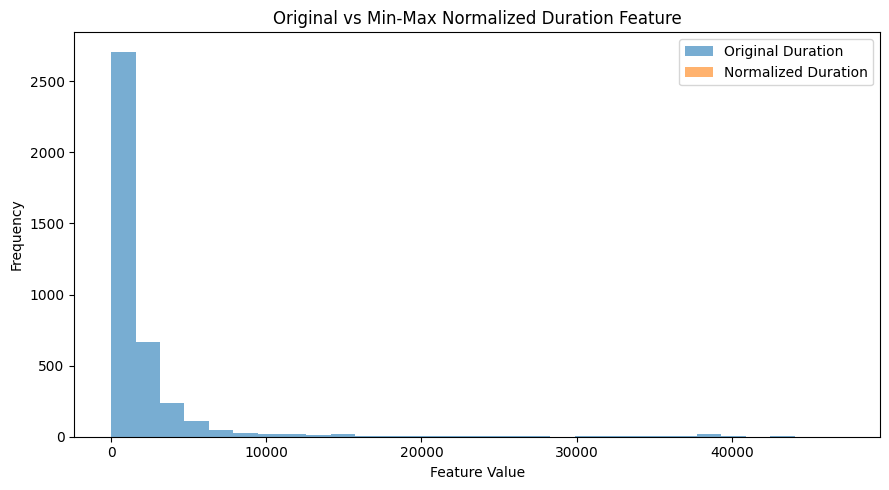

In [ ]:
feature = normalization_columns[0]
normalized_feature = feature + "_normalized"

plt.figure(figsize=(9, 5))
plt.hist(df_processed[feature].dropna(), bins=30, alpha=0.6, label="Original Duration")
plt.hist(df_normalized[normalized_feature].dropna(), bins=30, alpha=0.6, label="Normalized Duration")
plt.title("Original vs Min-Max Normalized Duration Feature")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Normalization Method and Justification

Min-Max normalization was applied to 16 complete quantitative duration features. These variables represent planned or effective logistics durations measured in minutes and therefore have meaningful numerical magnitude.

The transformation rescales each selected feature to a range between 0 and 1. This creates a common scale that can be useful for machine-learning techniques that are sensitive to differences in feature magnitude.

Normalization was not applied to process IDs, transport-leg IDs, or anonymized airport IDs. Although these fields may contain numeric-looking values, they function as identifiers or categorical codes rather than continuous measurements. Scaling such identifiers would create values with no meaningful logistics interpretation.

The 28 duration variables containing substantial missing information were also excluded from this normalization demonstration rather than being heavily imputed solely to permit scaling. This avoids introducing large amounts of artificial data.

The original duration variables were retained separately from the normalized features to preserve interpretability in minutes. In addition, Min-Max normalization does not remove statistical outliers and can be sensitive to extreme minimum and maximum values. Therefore, the normalized features should be used with awareness of the extreme-duration observations identified during the outlier assessment.

In [ ]:
print("Original raw shape:", df.shape)
print("Processed shape:", df_processed.shape)

print("\nDuplicate rows:", df_processed.duplicated().sum())

print("Negative duration values:",
      sum((df_processed[col].dropna() < 0).sum()
          for col in duration_columns))

print("Zero duration values:",
      sum((df_processed[col].dropna() == 0).sum()
          for col in duration_columns))

print("Columns removed for >=90% missingness:",
      len(high_missing_columns))

print("Remaining columns with missing values:",
      (df_processed.isnull().sum() > 0).sum())

print("Normalized features created:",
      df_normalized.shape[1])

Original raw shape: (3943, 98)
Processed shape: (3942, 68)

Duplicate rows: 0
Negative duration values: 0
Zero duration values: 0
Columns removed for >=90% missingness: 30
Remaining columns with missing values: 42
Normalized features created: 16


In [ ]:
final_df = pd.concat([df_processed, df_normalized], axis=1)

print("Final dataset shape:", final_df.shape)
print("Original variables retained:", df_processed.shape[1])
print("Normalized variables added:", df_normalized.shape[1])

display(final_df.head())

Final dataset shape: (3942, 84)
Original variables retained: 68
Normalized variables added: 16


,nr,i1_legid,i1_rcs_p,i1_rcs_e,i1_dep_1_p,i1_dep_1_e,i1_dep_1_place,i1_rcf_1_p,i1_rcf_1_e,i1_rcf_1_place,...,i1_dlv_p_normalized,i1_dlv_e_normalized,o_rcs_p_normalized,o_rcs_e_normalized,o_dep_1_p_normalized,o_dep_1_e_normalized,o_rcf_1_p_normalized,o_rcf_1_e_normalized,o_dlv_p_normalized,o_dlv_e_normalized
0,0.0,5182.0,199.0,218.0,210.0,215.0,609.0,935.0,736.0,256.0,...,0.067797,0.016906,0.201787,0.154201,0.098039,0.232636,0.260069,0.229027,0.047872,0.000773
1,1.0,6523.0,844.0,584.0,90.0,297.0,700.0,1935.0,1415.0,431.0,...,0.369800,0.063632,0.061570,0.061513,0.137255,0.021899,0.159887,0.095126,0.321809,0.000793
2,2.0,5878.0,4380.0,4119.0,90.0,280.0,456.0,905.0,547.0,700.0,...,0.369800,0.003517,0.029065,0.013078,0.098039,0.077709,0.233758,0.231745,0.027482,0.002712
3,3.0,1275.0,759.0,169.0,240.0,777.0,173.0,340.0,577.0,349.0,...,0.015922,0.005870,0.080560,0.064777,0.000000,0.070681,0.155839,0.173039,0.313830,0.000282
4,4.0,8117.0,1597.0,1485.0,150.0,241.0,411.0,585.0,612.0,128.0,...,0.416025,0.013784,0.002992,0.003632,0.058824,0.009234,0.037442,0.030078,0.345745,0.008562


In [ ]:
final_df.to_csv(
    "/content/Task_2_Processed_Logistics_Dataset.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


## Reflection: Impact of Data Quality on Logistics Analytics

Data quality has a direct impact on the reliability of logistics analytics and operational decision-making. In this project, the initial inspection showed that a simple missing-value check was not sufficient because the dataset used both standard missing values and non-standard `?` placeholders. This demonstrates why preprocessing should combine automated checks with an understanding of how the source dataset represents unavailable information.

The preprocessing process also showed that cleaning should not mean automatically deleting or replacing every unusual observation. One completely empty record was removed because it contained no usable information, while 30 variables with at least 90% missingness were excluded from the analysis-ready dataset because reliable imputation would require creating substantially more information than was actually observed. In contrast, partially incomplete variables below this threshold were retained rather than aggressively imputed, preserving the distinction between observed and unavailable logistics information.

Outlier analysis provided another important lesson. The IQR method identified several extreme duration observations, but additional validation found no negative or zero durations. Since unusually long freight durations may represent genuine delays, disruptions, or exceptional transport processes, the statistical outliers were retained rather than automatically deleted.

Data types and transformations must also reflect business meaning. Planned and effective duration variables were converted to numerical format because they represent minutes, while process IDs, transport-leg IDs, and anonymized airport IDs were not treated as continuous measurements. Min-Max normalization was applied only to 16 complete quantitative duration features, while the original duration values were preserved for interpretation.

Overall, high-quality logistics preprocessing requires a balance between correcting genuine data-quality problems and preserving meaningful operational variation. Poor preprocessing can distort delivery-performance measures, hide exceptional events, create artificial patterns, and lead to unreliable decisions about transportation performance and resource allocation. A transparent, validated, and business-aware preprocessing pipeline therefore provides a stronger foundation for subsequent descriptive, predictive, and optimization-oriented logistics analysis.

## Data Quality Recommendations for Future Logistics Analysis

Based on the preprocessing findings, the following practices are recommended for future logistics data collection and analysis:

1. **Standardize missing-value representation:** Missing information should be stored using a consistent standard such as `NaN` or database null values rather than symbols such as `?`. This will reduce the risk of missing information being incorrectly interpreted as valid categorical data.

2. **Improve completeness of freight-event records:** Several event-related variables contained very high levels of missing information, including some exceeding 90%. Data-capture procedures should therefore be reviewed to determine why planned, effective, and location-related event information is frequently unavailable.

3. **Preserve semantic data types:** Process IDs, transport-leg IDs, and anonymized airport IDs should be treated as identifiers or categorical variables rather than continuous numerical measurements. Duration fields should remain numerical because arithmetic operations on time measurements have operational meaning.

4. **Avoid indiscriminate imputation:** Variables with substantial missingness should not automatically be filled using mean, median, or mode values. The amount of missingness, variable meaning, and intended analytical use should be evaluated before selecting an imputation strategy.

5. **Investigate extreme durations with operational context:** IQR-based analysis identified extreme duration observations, but no negative or zero durations were found. Extreme positive durations should therefore be investigated against operational events before removal because they may represent genuine freight delays or disruptions.

6. **Apply scaling selectively:** Normalization should be restricted to meaningful quantitative features when required by the analytical method. Identifiers and categorical codes should not be normalized.

7. **Maintain raw and processed datasets separately:** The original source data should remain unchanged while preprocessing is performed on separate working copies. This supports reproducibility, auditing, and comparison between raw and analysis-ready data.

8. **Validate preprocessing before modeling:** Missingness, duplicates, data types, value ranges, and transformation outputs should be checked again after preprocessing. This helps prevent cleaning decisions from introducing new errors into later logistics analytics.

## Before vs After Preprocessing Summary

In [ ]:
summary_data = {
    "Metric": [
        "Number of Rows",
        "Original Variables",
        "Completely Empty Rows",
        "Exact Duplicate Rows",
        "Non-standard '?' Missing Placeholders",
        "Columns Removed for >=90% Missingness",
        "Variables Retained After Cleaning",
        "Remaining Variables with Missing Values",
        "Duration Features Converted to Numeric",
        "Normalized Features Added",
        "Final Number of Variables"
    ],
    "Before Preprocessing": [
        3943,
        98,
        1,
        0,
        210186,
        0,
        98,
        72,
        0,
        0,
        98
    ],
    "After Preprocessing": [
        3942,
        98,
        0,
        0,
        0,
        30,
        68,
        42,
        44,
        16,
        84
    ]
}

preprocessing_summary = pd.DataFrame(summary_data)
preprocessing_summary

,Metric,Before Preprocessing,After Preprocessing
0,Number of Rows,3943,3942
1,Original Variables,98,98
2,Completely Empty Rows,1,0
3,Exact Duplicate Rows,0,0
4,Non-standard '?' Missing Placeholders,210186,0
5,Columns Removed for >=90% Missingness,0,30
6,Variables Retained After Cleaning,98,68
7,Remaining Variables with Missing Values,72,42
8,Duration Features Converted to Numeric,0,44
9,Normalized Features Added,0,16


In [ ]:
import pandas as pd

### Interpretation

The preprocessing pipeline reduced the dataset from 3,943 to 3,942 records by removing one completely empty row. No exact duplicate records were identified. A major data-quality issue was the presence of 210,186 non-standard "?" placeholders, which were converted into standard missing values for accurate assessment.

Thirty variables with at least 90% missingness were removed because their extremely limited observed information made reliable imputation unsuitable for this project. This threshold was used as a project-specific conservative rule rather than a universal preprocessing standard. The resulting dataset retained 68 original variables, including 44 planned or effective duration features converted to numeric format based on the official dataset documentation.

Forty-two retained variables still contain missing values. These values were intentionally not filled through indiscriminate imputation because doing so could introduce artificial logistics information and distort subsequent analysis. Sixteen complete quantitative duration features were additionally normalized using Min-Max scaling while their original values in minutes were preserved.

After preprocessing and normalization, the final dataset contains 3,942 records and 84 variables. The processed dataset is therefore suitable for analyses using appropriately selected features, while analyses involving the remaining incomplete variables will require additional task-specific missing-data treatment.

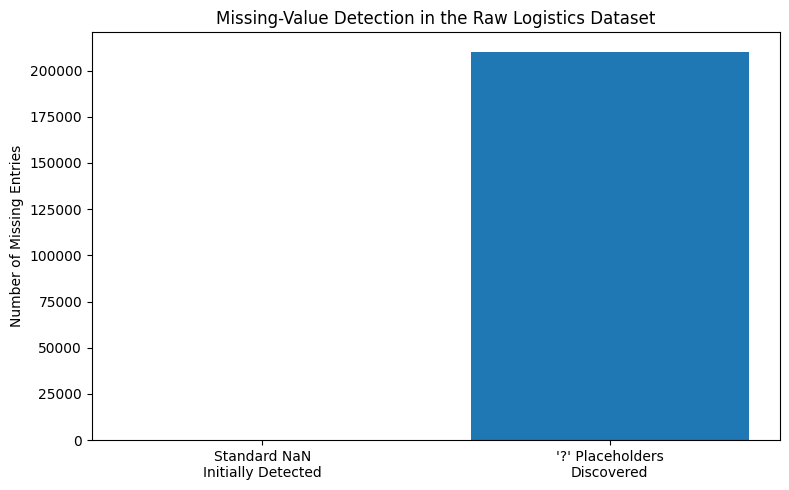

In [ ]:
import matplotlib.pyplot as plt

labels = ["Standard NaN\nInitially Detected", "'?' Placeholders\nDiscovered"]
values = [98, 210186]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.title("Missing-Value Detection in the Raw Logistics Dataset")
plt.ylabel("Number of Missing Entries")
plt.tight_layout()
plt.show()

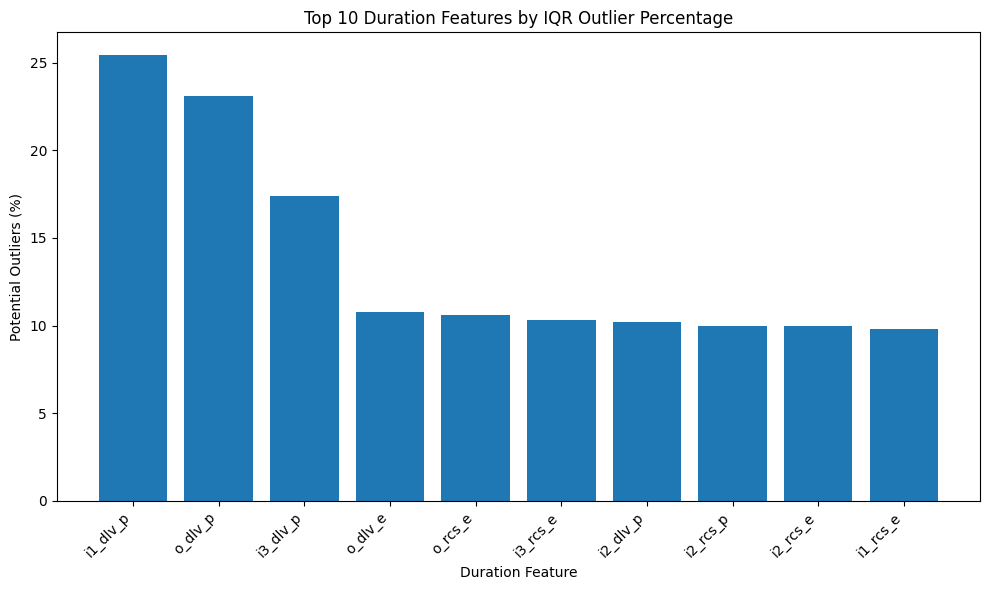

In [ ]:
outlier_chart = outlier_summary.sort_values(
    "Outlier_Percentage", ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.bar(outlier_chart["Column"], outlier_chart["Outlier_Percentage"])
plt.title("Top 10 Duration Features by IQR Outlier Percentage")
plt.xlabel("Duration Feature")
plt.ylabel("Potential Outliers (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()